Questions :

1.1 Chargement des données

● Votre première tâche consiste à importer les bibliothèques Python nécessaires pour
réaliser ce TD, telles que Pandas et Numpy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

● Ensuite, chargez le fichier de données correspondant (solar2021UNLV.csv) dans
un DataFrame nommé df_solar. Quelle colonne devez-vous utiliser comme index ?
Pourquoi ?

In [2]:
df_solar = pd.read_csv('../dataset/solar2021UNLV.csv', index_col=0, parse_dates=True)
# Supprime toute colonne auto-nommée 'Unnamed...' qui vient souvent de l'export CSV avec index
df_solar = df_solar.loc[:, ~df_solar.columns.str.contains('^Unnamed')]
# La colonne d'index choisie est la première (probablement Date/Time) car elle permet de réaliser
# des analyses temporelles précises et de manipuler les données par tranches horaires.
df_solar.head()

,year,DOY,PST,dni,ghi,Global UVA [W/m^2],Global UVE [W/m^2],Global UVE [Index],temp,Avg Wind Speed @ 30ft [m/s],Avg Wind Direction @ 30ft [deg from N],Peak Wind Speed @ 30ft [m/s],UVSAET Temp [deg C],Logger Temp [deg C],Logger Battery [VDC],Wind Chill Temp [deg C],dhi,Zenith Angle [degrees],Azimuth Angle [degrees],Airmass
2021-01-01 00:00:00-08:00,2021,1,0,0.835528,-3.09367,-0.011,0.0,0.004,10.62,7.077,5.202,10.680,24.88,18.96,13.35,7.804,0.0,166.453,15.9978,-7999.0
2021-01-01 00:01:00-08:00,2021,1,1,0.835529,-3.08898,-0.011,0.0,0.004,10.65,5.321,8.640,9.210,24.87,18.96,13.35,8.390,0.0,166.396,16.9448,-7999.0
2021-01-01 00:02:00-08:00,2021,1,2,0.835529,-2.54994,-0.011,0.0,0.004,10.61,4.655,7.555,7.644,24.81,18.96,13.35,8.550,0.0,166.335,17.8867,-7999.0
2021-01-01 00:03:00-08:00,2021,1,3,0.835530,-2.53119,-0.016,0.0,0.003,10.56,3.842,34.190,6.468,24.75,18.95,13.35,8.860,0.0,166.272,18.8207,-7999.0
2021-01-01 00:04:00-08:00,2021,1,4,0.835530,-2.86868,-0.016,0.0,0.003,10.57,5.771,41.970,7.448,24.78,18.95,13.35,8.090,0.0,166.205,19.7466,-7999.0


1.2 Exploration des données

Dans cette partie, nous allons examiner le jeu de données afin de vous permettre de mieuxcomprendre les informations dont vous disposez.

1. Quelle est la taille du DataFrame chargé ?

In [3]:
print(f"La taille du DataFrame est : {df_solar.shape}")

La taille du DataFrame est : (525600, 20)


2. Affichez les 10 premières lignes et les 10 dernières lignes du DataFrame df_solar.

In [4]:
print("10 premières lignes :")
display(df_solar.head(10))
print("\n10 dernières lignes :")
display(df_solar.tail(10))

10 premières lignes :


,year,DOY,PST,dni,ghi,Global UVA [W/m^2],Global UVE [W/m^2],Global UVE [Index],temp,Avg Wind Speed @ 30ft [m/s],Avg Wind Direction @ 30ft [deg from N],Peak Wind Speed @ 30ft [m/s],UVSAET Temp [deg C],Logger Temp [deg C],Logger Battery [VDC],Wind Chill Temp [deg C],dhi,Zenith Angle [degrees],Azimuth Angle [degrees],Airmass
2021-01-01 00:00:00-08:00,2021,1,0,0.835528,-3.09367,-0.011,0.0,0.004,10.62,7.077,5.202,10.680,24.88,18.96,13.35,7.804,0.0,166.453,15.9978,-7999.0
2021-01-01 00:01:00-08:00,2021,1,1,0.835529,-3.08898,-0.011,0.0,0.004,10.65,5.321,8.640,9.210,24.87,18.96,13.35,8.390,0.0,166.396,16.9448,-7999.0
2021-01-01 00:02:00-08:00,2021,1,2,0.835529,-2.54994,-0.011,0.0,0.004,10.61,4.655,7.555,7.644,24.81,18.96,13.35,8.550,0.0,166.335,17.8867,-7999.0
2021-01-01 00:03:00-08:00,2021,1,3,0.835530,-2.53119,-0.016,0.0,0.003,10.56,3.842,34.190,6.468,24.75,18.95,13.35,8.860,0.0,166.272,18.8207,-7999.0
2021-01-01 00:04:00-08:00,2021,1,4,0.835530,-2.86868,-0.016,0.0,0.003,10.57,5.771,41.970,7.448,24.78,18.95,13.35,8.090,0.0,166.205,19.7466,-7999.0
2021-01-01 00:05:00-08:00,2021,1,5,0.835530,-2.91087,-0.010,0.0,0.004,10.56,3.486,13.700,4.704,24.87,18.95,13.35,9.000,0.0,166.135,20.6640,-7999.0
2021-01-01 00:06:00-08:00,2021,1,6,0.327250,-2.53119,-0.011,0.0,0.004,10.47,3.069,27.540,4.508,24.88,18.93,13.35,9.100,0.0,166.062,21.5727,-7999.0
2021-01-01 00:07:00-08:00,2021,1,7,0.083553,-2.87806,-0.010,0.0,0.004,10.47,5.178,49.940,7.840,24.83,18.92,13.35,8.200,0.0,165.986,22.4729,-7999.0
2021-01-01 00:08:00-08:00,2021,1,8,0.591835,-3.09368,-0.014,0.0,0.004,10.51,5.870,38.450,8.130,24.77,18.92,13.35,7.992,0.0,165.908,23.3637,-7999.0
2021-01-01 00:09:00-08:00,2021,1,9,0.835531,-3.06087,-0.016,0.0,0.003,10.58,4.800,6.056,6.762,24.77,18.92,13.35,8.440,0.0,165.826,24.2449,-7999.0



10 dernières lignes :


,year,DOY,PST,dni,ghi,Global UVA [W/m^2],Global UVE [W/m^2],Global UVE [Index],temp,Avg Wind Speed @ 30ft [m/s],Avg Wind Direction @ 30ft [deg from N],Peak Wind Speed @ 30ft [m/s],UVSAET Temp [deg C],Logger Temp [deg C],Logger Battery [VDC],Wind Chill Temp [deg C],dhi,Zenith Angle [degrees],Azimuth Angle [degrees],Airmass
2021-12-31 23:50:00-08:00,2021,365,2350,0.0,-2.53035,-0.015,0.0,0.003,7.844,9.200,13.060,12.94,24.77,22.70,13.27,3.641,0.0,166.861,6.28500,-7999.0
2021-12-31 23:51:00-08:00,2021,365,2351,0.0,-2.39915,-0.005,0.0,0.005,7.839,7.414,12.880,12.54,24.99,22.69,13.27,4.133,0.0,166.837,7.29109,-7999.0
2021-12-31 23:52:00-08:00,2021,365,2352,0.0,-2.11800,-0.004,0.0,0.004,7.836,9.470,7.026,13.33,24.93,22.68,13.27,3.542,0.0,166.809,8.29352,-7999.0
2021-12-31 23:53:00-08:00,2021,365,2353,0.0,-2.01022,-0.001,0.0,0.006,7.828,9.550,9.310,14.80,24.93,22.67,13.27,3.530,0.0,166.778,9.29556,-7999.0
2021-12-31 23:54:00-08:00,2021,365,2354,0.0,-1.96805,-0.001,0.0,0.005,7.832,10.220,7.549,14.70,24.93,22.67,13.27,3.413,0.0,166.744,10.28900,-7999.0
2021-12-31 23:55:00-08:00,2021,365,2355,0.0,-1.96805,-0.002,0.0,0.006,7.832,9.410,8.170,14.21,24.93,22.65,13.27,3.587,0.0,166.706,11.27750,-7999.0
2021-12-31 23:56:00-08:00,2021,365,2356,0.0,-1.96805,-0.001,0.0,0.005,7.835,8.010,11.470,13.62,24.92,22.64,13.27,3.984,0.0,166.665,12.25790,-7999.0
2021-12-31 23:57:00-08:00,2021,365,2357,0.0,-1.96805,-0.001,0.0,0.006,7.832,9.400,15.330,13.92,24.91,22.64,13.27,3.562,0.0,166.620,13.23480,-7999.0
2021-12-31 23:58:00-08:00,2021,365,2358,0.0,-1.96805,-0.001,0.0,0.006,7.793,7.837,14.450,12.45,24.91,22.64,13.27,3.934,0.0,166.572,14.20580,-7999.0
2021-12-31 23:59:00-08:00,2021,365,2359,0.0,-1.96805,-0.002,0.0,0.005,7.762,8.160,5.118,12.05,24.91,22.64,13.27,3.786,0.0,166.521,15.17010,-7999.0


3. Listez les noms des colonnes présentes dans ce jeu de données ainsi que leur type
de données.

In [5]:
print("Informations sur les colonnes et types de données :")
df_solar.info()

Informations sur les colonnes et types de données :
<class 'pandas.DataFrame'>
DatetimeIndex: 525600 entries, 2021-01-01 00:00:00-08:00 to 2021-12-31 23:59:00-08:00
Data columns (total 20 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   year                                    525600 non-null  int64  
 1   DOY                                     525600 non-null  int64  
 2   PST                                     525600 non-null  int64  
 3   dni                                     525600 non-null  float64
 4   ghi                                     525600 non-null  float64
 5   Global UVA [W/m^2]                      525600 non-null  float64
 6   Global UVE [W/m^2]                      525600 non-null  float64
 7   Global UVE [Index]                      525600 non-null  float64
 8   temp                                    525600 non-null  float64
 9   Avg Wind Speed @ 30ft [m/s]

4. Quelles variables (features) peuvent contenir des valeurs aberrantes (outliers) ?
Vous devez justifier votre réponse à l’aide d’un graphique, par exemple un boxplot.


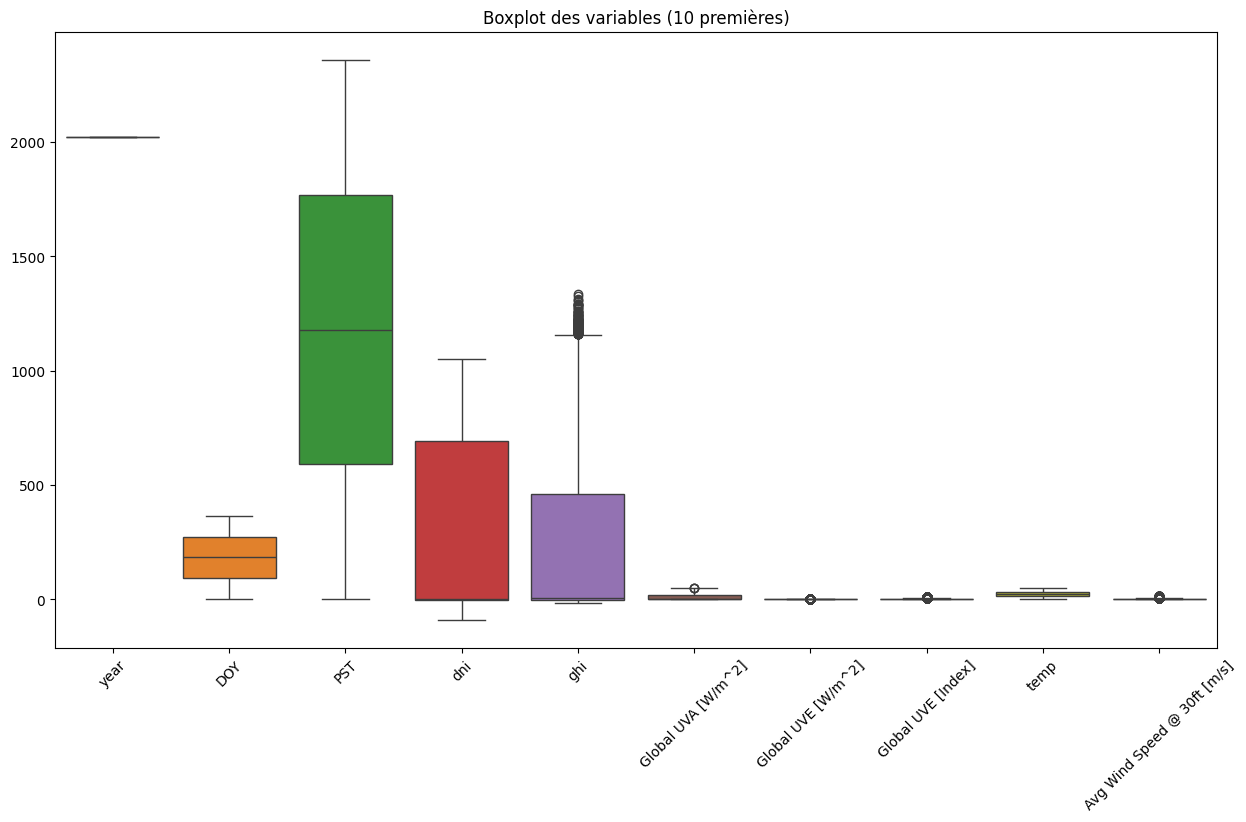

In [6]:
# Sélection de colonnes numériques pertinentes pour détecter les outliers
# On filtre pour ne garder que les colonnes numériques
numeriques = df_solar.select_dtypes(include=[np.number])
plt.figure(figsize=(15, 8))
sns.boxplot(data=numeriques.iloc[:, :10]) # On affiche les 10 premières colonnes numériques pour la lisibilité
plt.xticks(rotation=45)
plt.title("Boxplot des variables (10 premières)")
plt.show()
# Certaines variables comme GHI ou DNI peuvent présenter beaucoup d'outliers si les capteurs ont des pics de mesure
# ou si l'on compare des valeurs de nuit (0) avec des valeurs de plein soleil.

1.3 Manipulation des données

5. Comme vous avez pu le remarquer, le DataFrame df contient une ou plusieurs
colonnes inutiles. Supprimez la ou les colonnes non souhaitées.

In [7]:
# Suppression des colonnes potentiellement inutiles (redondantes avec l'index temporel)
cols_to_drop = ['year', 'DOY', 'PST']
df_solar = df_solar.drop(columns=[c for c in cols_to_drop if c in df_solar.columns])
print("Colonnes restantes :", df_solar.columns.tolist())
df_solar.head()

Colonnes restantes : ['dni', 'ghi', 'Global UVA [W/m^2]', 'Global UVE [W/m^2]', 'Global UVE [Index]', 'temp', 'Avg Wind Speed @ 30ft [m/s]', 'Avg Wind Direction @ 30ft [deg from N]', 'Peak Wind Speed @ 30ft [m/s]', 'UVSAET Temp [deg C]', 'Logger Temp [deg C]', 'Logger Battery [VDC]', 'Wind Chill Temp [deg C]', 'dhi', 'Zenith Angle [degrees]', 'Azimuth Angle [degrees]', 'Airmass']


,dni,ghi,Global UVA [W/m^2],Global UVE [W/m^2],Global UVE [Index],temp,Avg Wind Speed @ 30ft [m/s],Avg Wind Direction @ 30ft [deg from N],Peak Wind Speed @ 30ft [m/s],UVSAET Temp [deg C],Logger Temp [deg C],Logger Battery [VDC],Wind Chill Temp [deg C],dhi,Zenith Angle [degrees],Azimuth Angle [degrees],Airmass
2021-01-01 00:00:00-08:00,0.835528,-3.09367,-0.011,0.0,0.004,10.62,7.077,5.202,10.680,24.88,18.96,13.35,7.804,0.0,166.453,15.9978,-7999.0
2021-01-01 00:01:00-08:00,0.835529,-3.08898,-0.011,0.0,0.004,10.65,5.321,8.640,9.210,24.87,18.96,13.35,8.390,0.0,166.396,16.9448,-7999.0
2021-01-01 00:02:00-08:00,0.835529,-2.54994,-0.011,0.0,0.004,10.61,4.655,7.555,7.644,24.81,18.96,13.35,8.550,0.0,166.335,17.8867,-7999.0
2021-01-01 00:03:00-08:00,0.835530,-2.53119,-0.016,0.0,0.003,10.56,3.842,34.190,6.468,24.75,18.95,13.35,8.860,0.0,166.272,18.8207,-7999.0
2021-01-01 00:04:00-08:00,0.835530,-2.86868,-0.016,0.0,0.003,10.57,5.771,41.970,7.448,24.78,18.95,13.35,8.090,0.0,166.205,19.7466,-7999.0


6. Vérifiez la présence de valeurs manquantes (NaN) dans le DataFrame df_ref, puis
supprimez toutes les lignes contenant des valeurs manquantes.

In [8]:
print(f"Nombre de valeurs manquantes par colonne :\n{df_solar.isnull().sum()}")
df_solar = df_solar.dropna()
print(f"\nTaille après suppression des NaNs : {df_solar.shape}")

Nombre de valeurs manquantes par colonne :
dni                                       0
ghi                                       0
Global UVA [W/m^2]                        0
Global UVE [W/m^2]                        0
Global UVE [Index]                        0
temp                                      0
Avg Wind Speed @ 30ft [m/s]               0
Avg Wind Direction @ 30ft [deg from N]    0
Peak Wind Speed @ 30ft [m/s]              0
UVSAET Temp [deg C]                       0
Logger Temp [deg C]                       0
Logger Battery [VDC]                      0
Wind Chill Temp [deg C]                   0
dhi                                       0
Zenith Angle [degrees]                    0
Azimuth Angle [degrees]                   0
Airmass                                   0
dtype: int64

Taille après suppression des NaNs : (525600, 17)


7. Vérifiez la présence de doublons dans ce DataFrame, puis supprimez toutes les
lignes dupliquées.

In [9]:
print(f"Nombre de doublons détectés : {df_solar.duplicated().sum()}")
df_solar = df_solar.drop_duplicates()
print(f"Taille après suppression des doublons : {df_solar.shape}")

Nombre de doublons détectés : 0
Taille après suppression des doublons : (525600, 17)


1.4 Analyse des données et visualisation

8. Quelle est la valeur maximale de la variable “GHI” et à quelle date correspond-elle ?

In [10]:
max_ghi = df_solar['ghi'].max()
date_max_ghi = df_solar['ghi'].idxmax()
print(f"La valeur maximale de GHI est : {max_ghi} W/m²")
print(f"Elle a été mesurée le : {date_max_ghi}")

La valeur maximale de GHI est : 1337.17 W/m²
Elle a été mesurée le : 2021-04-27 12:20:00-08:00


9. Quelle est la valeur moyenne de “GHI” :

○ globale ?

In [11]:
mean_ghi_global = df_solar['ghi'].mean()
print(f"Valeur moyenne globale de GHI : {mean_ghi_global:.2f} W/m²")

Valeur moyenne globale de GHI : 233.31 W/m²


○ par mois ?

In [12]:
mean_ghi_month = df_solar.groupby(df_solar.index.month)['ghi'].mean()
print("Moyenne de GHI par mois (1=Janvier, 12=Décembre) :")
print(mean_ghi_month)

Moyenne de GHI par mois (1=Janvier, 12=Décembre) :
1     125.318109
2     186.490682
3     232.542912
4     303.898543
5     336.267422
6     322.771522
7     295.872890
8     297.437681
9     251.901517
10    186.880923
11    150.567320
12    108.345687
Name: ghi, dtype: float64


○ par saison ?

In [13]:
def get_season(month):
    if month in [12, 1, 2]: return 'Hiver'
    elif month in [3, 4, 5]: return 'Printemps'
    elif month in [6, 7, 8]: return 'Été'
    else: return 'Automne'

df_solar['season'] = df_solar.index.month.map(get_season)
mean_ghi_season = df_solar.groupby('season')['ghi'].mean()
print("Moyenne de GHI par saison :")
print(mean_ghi_season)

Moyenne de GHI par saison :
season
Automne      196.344766
Hiver        138.503519
Printemps    290.761703
Été          305.171450
Name: ghi, dtype: float64


10. Tracez l’évolution de “GHI” pour une journée donnée.
Puis, tracez un second graphique pour cinq jours consécutifs à partir d’une date
choisie.

Vous pouvez extraire les valeurs de GHI pour une période donnée à partir de la
série temporelle en utilisant le slicing suivant :
df_ref['2021-06-01':'2021-06-02']['ghi']

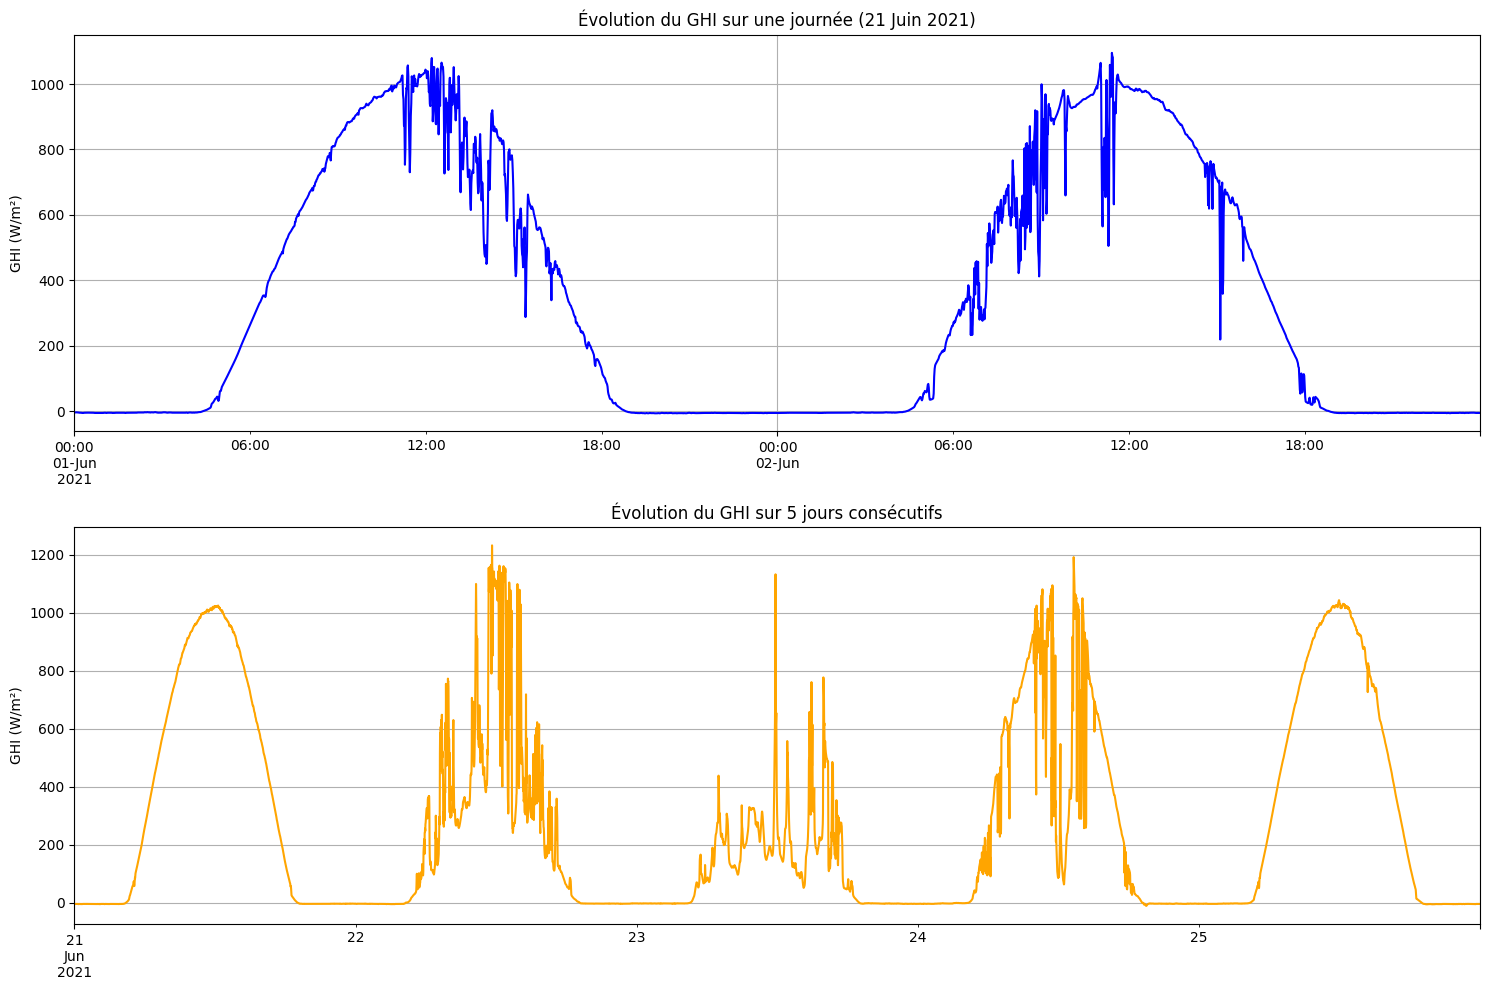

In [14]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
df_solar['2021-06-01':'2021-06-02']['ghi'].plot(color='blue')
plt.title("Évolution du GHI sur une journée (21 Juin 2021)")
plt.ylabel("GHI (W/m²)")
plt.grid(True)

plt.subplot(2, 1, 2)
df_solar['2021-06-21':'2021-06-25']['ghi'].plot(color='orange')
plt.title("Évolution du GHI sur 5 jours consécutifs")
plt.ylabel("GHI (W/m²)")
plt.grid(True)

plt.tight_layout()
plt.show()

11. Tracez la variation de “GHI” par jour et par mois.
Pouvez-vous réaliser cela sans ajouter de nouvelles colonnes correspondant au jour
et au mois ? Si oui, expliquez comment

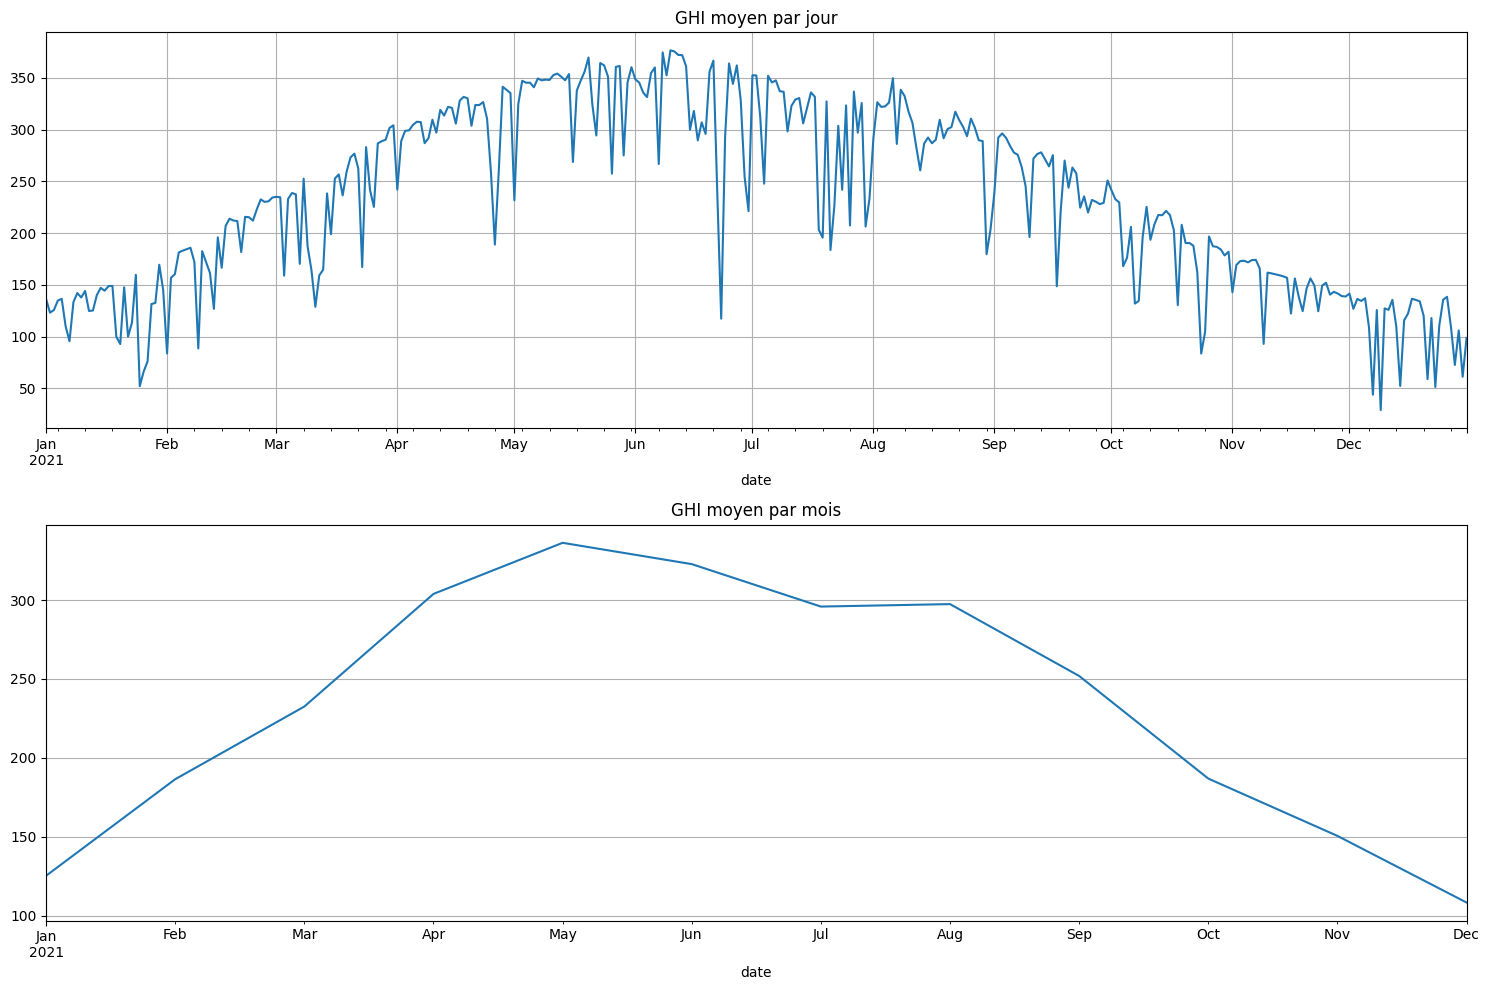

In [15]:
plt.figure(figsize=(15, 10))

df_solar['date'] = pd.to_datetime(df_solar.index)
df_solar = df_solar.set_index('date')

ghi_jour = df_solar['ghi'].resample('D').mean()
ghi_mois = df_solar['ghi'].resample('ME').mean()

plt.subplot(2, 1, 1)
ghi_jour.plot(title="GHI moyen par jour")
plt.grid(True)

plt.subplot(2, 1, 2)
ghi_mois.plot(title="GHI moyen par mois")
plt.grid(True)

plt.tight_layout()
plt.show()

12. Tracez l’évolution de :

○ GHI

○ DHI

○ DNI

○ la température

en fonction de la date (jour), sous forme de sous-graphiques (subplots), un graphique par
variable.

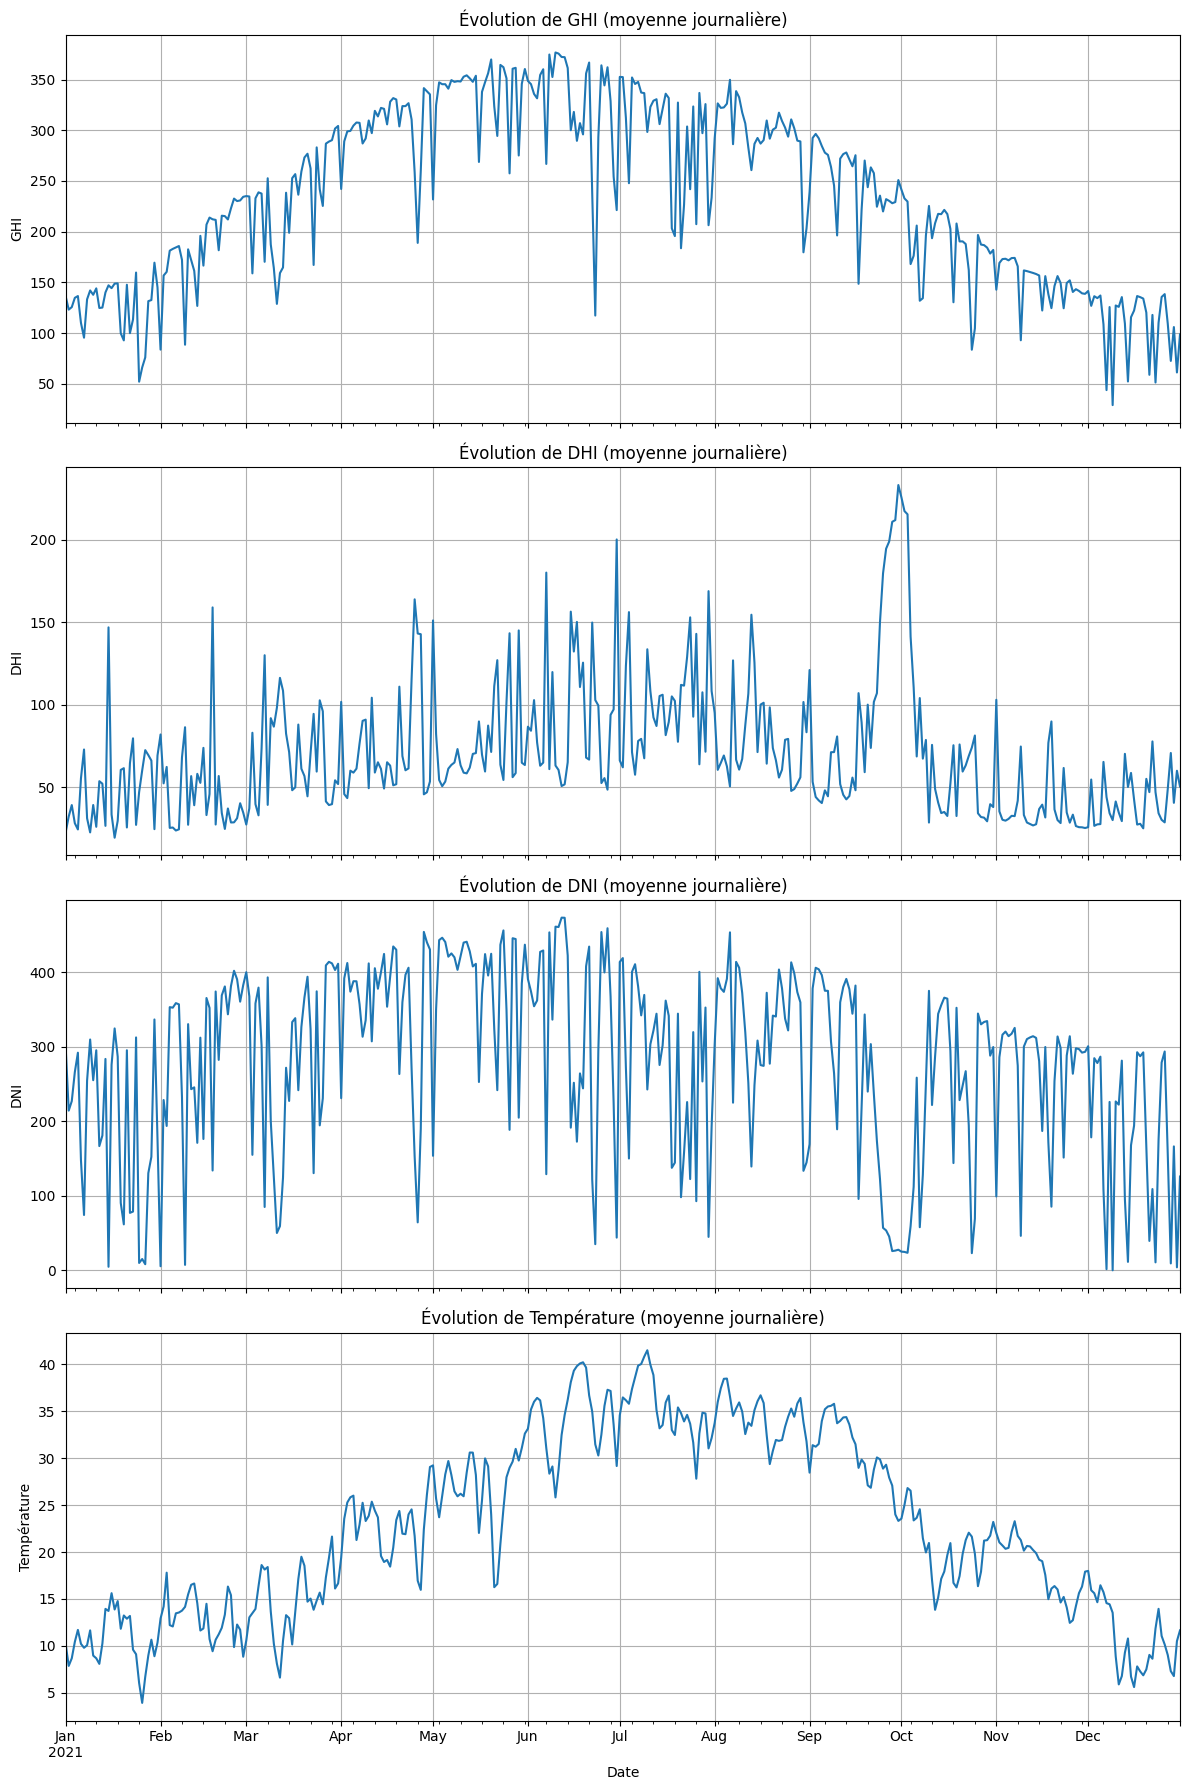

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(12, 18), sharex=True)

variables = ['ghi', 'dhi', 'dni', 'temp']
titles = ['GHI', 'DHI', 'DNI', 'Température']

for ax, var, title in zip(axes, variables, titles):
    if var not in df_solar.columns:
        raise KeyError(f"La colonne '{var}' est absente du DataFrame")
    # tracer en agrégat journalier (moyenne) pour lisibilité
    df_solar[var].resample('D').mean().plot(ax=ax)
    ax.set_title(f"Évolution de {title} (moyenne journalière)")
    ax.set_ylabel(title)
    ax.grid(True)

axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.show()

13. Tracez la variation de la température en fonction du rayonnement solaire “GHI”.
Que pouvez-vous conclure sur la relation entre ces deux variables ?

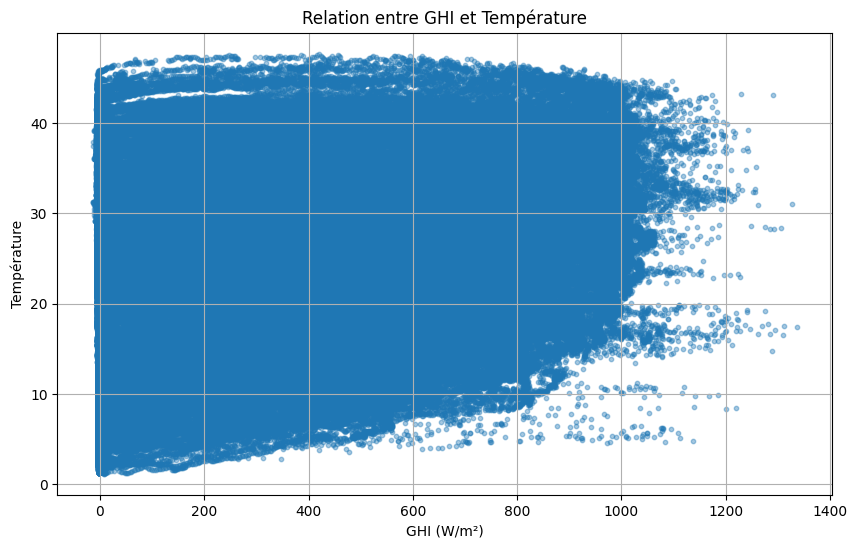

Corrélation GHI vs Température : 0.317


In [17]:
# Question 13 : GHI vs Température
plt.figure(figsize=(10, 6))
plt.scatter(df_solar['ghi'], df_solar['temp'], alpha=0.4, s=10)
plt.title('Relation entre GHI et Température')
plt.xlabel('GHI (W/m²)')
plt.ylabel('Température')
plt.grid(True)
plt.show()

corr_ghi_temp = df_solar['ghi'].corr(df_solar['temp'])
print(f"Corrélation GHI vs Température : {corr_ghi_temp:.3f}")

14. Tracez la matrice de corrélation du jeu de données sous forme de carte
thermique (heatmap) afin de mieux comprendre les relations entre toutes les
variables du dataset.

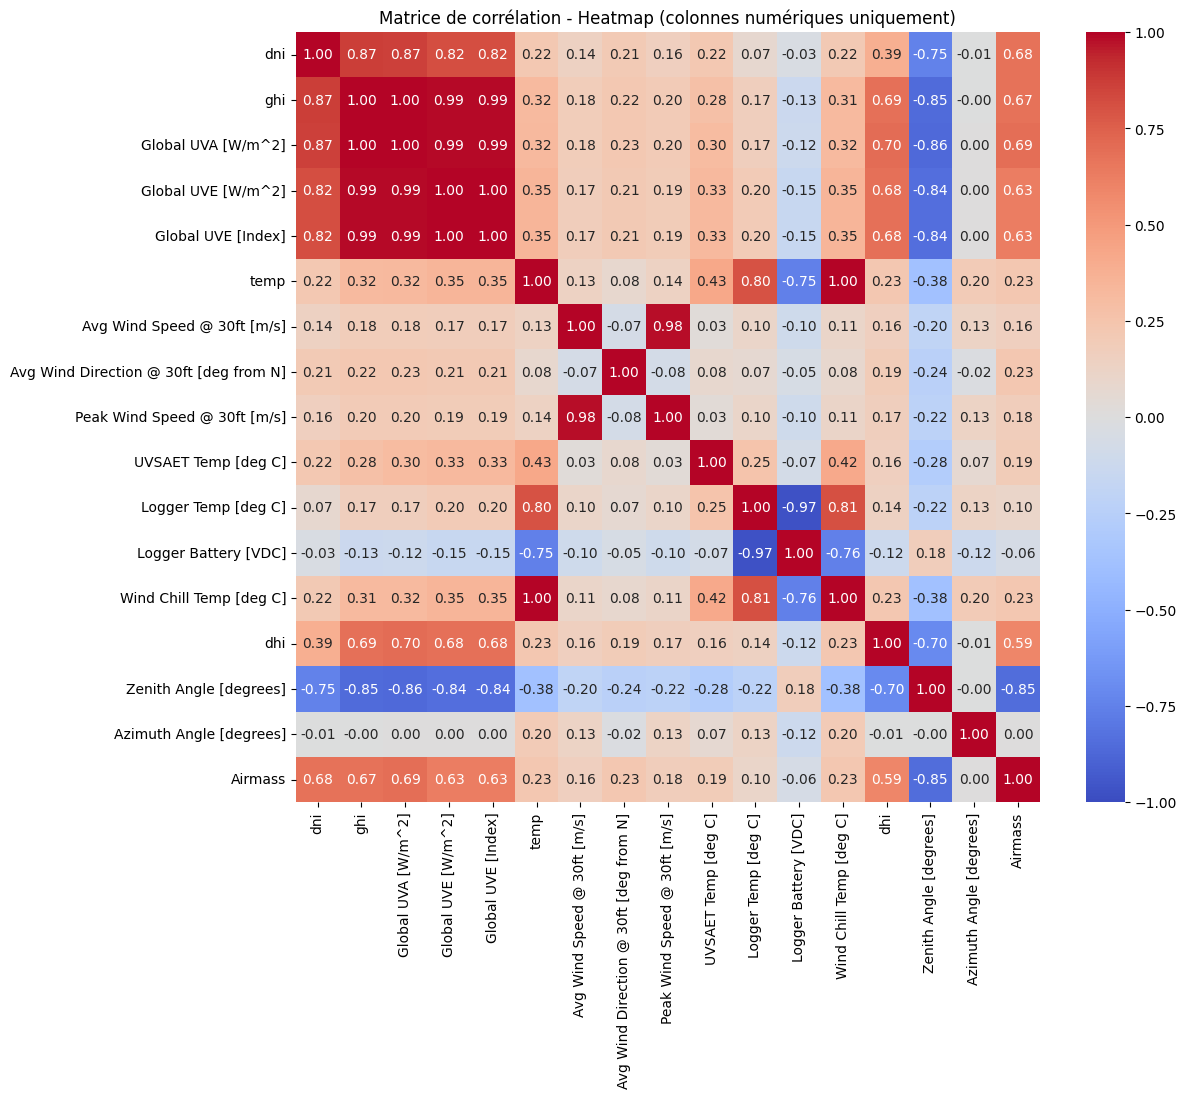

Matrice de corrélation stockée dans la variable corr


In [18]:
import seaborn as sns
plt.figure(figsize=(12, 10))

corr = df_solar.select_dtypes(include='number').corr()
heatmap = sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
heatmap.set_title('Matrice de corrélation - Heatmap (colonnes numériques uniquement)')
plt.show()

print('Matrice de corrélation stockée dans la variable corr')

● Utilisez la fonction corr() de Pandas pour calculer la matrice de corrélation.

In [19]:
# Le calcul de corrélations a déjà été fait ci-dessus (corr variable).
# Vérifions quelques valeurs précises
print(corr[['ghi', 'dhi', 'dni', 'temp']].loc[['ghi', 'dhi', 'dni', 'temp']])

           ghi       dhi       dni      temp
ghi   1.000000  0.686300  0.870664  0.317193
dhi   0.686300  1.000000  0.386636  0.233900
dni   0.870664  0.386636  1.000000  0.219958
temp  0.317193  0.233900  0.219958  1.000000


● Stockez le résultat dans une variable appelée corr

In [20]:
# Affichage succinct des corrélations de référence
print('Corrélation GHI-DHI :', corr.loc['ghi', 'dhi'])
print('Corrélation GHI-DNI :', corr.loc['ghi', 'dni'])
print('Corrélation GHI-Temp :', corr.loc['ghi', 'temp'])

Corrélation GHI-DHI : 0.6862995498358833
Corrélation GHI-DNI : 0.870663836036852
Corrélation GHI-Temp : 0.3171927796606446


Ces valeurs permettent d’analyser les relations entre les colonnes :

- Diagonale principale = 1 : chaque variable est parfaitement corrélée avec elle-même (corr(X,X)=1).
- Matrice symétrique : corr(X,Y)=corr(Y,X), donc les valeurs se reflètent par rapport à la diagonale.
- Corrélation proche de zéro signifie faible relation linéaire ; proche de +1 ou -1, relation linéaire forte (positive ou négative).

● Une corrélation parfaitement négative est égale à –1

Ensuite, répondez aux questions suivantes :

● En observant la diagonale principale (de gauche à droite) de la matrice de
corrélation, pourquoi cette diagonale est-elle remplie de valeurs égales à 1 ?
Expliquez.

● Toujours en observant la matrice de corrélation, vous remarquerez que les valeurs
sont symétriques : les valeurs situées sous la diagonale ont un équivalent au-dessus.
Pourquoi la matrice de corrélation est-elle symétrique ? Expliquez

● De nombreuses paires de variables présentent une corrélation proche de zéro.
Que signifie une corrélation proche de zéro ?

● Quelles sont les variables qui présentent les corrélations les plus fortes ?
Pouvez-vous les lister ?

15. Tracez un nouveau graphique de corrélation entre le rayonnement “GHI” et les
autres variables du dataset.

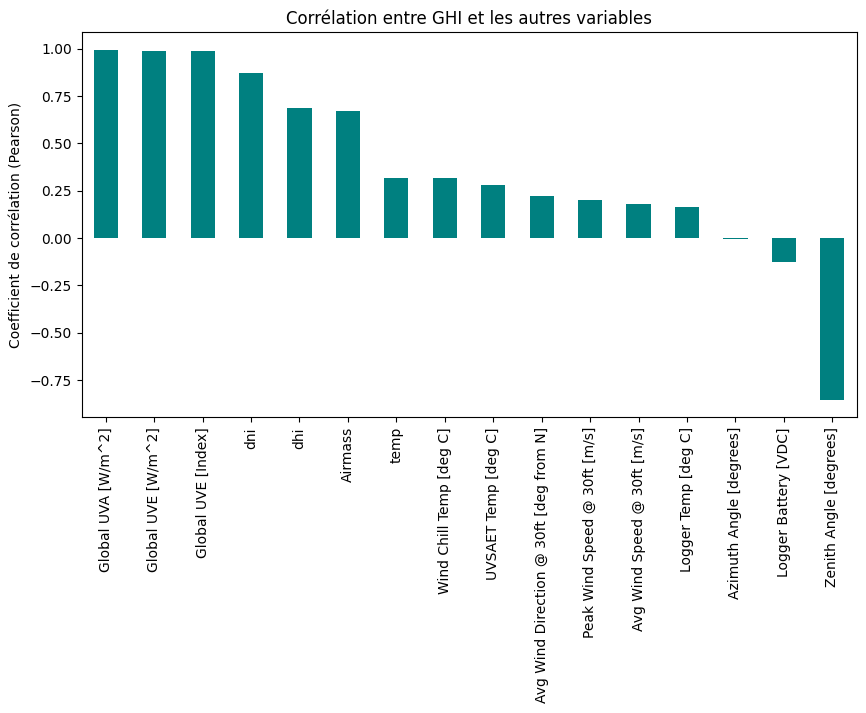

Variables les plus corrélées à GHI :
Global UVA [W/m^2]    0.995035
Global UVE [W/m^2]    0.987408
Global UVE [Index]    0.987349
dni                   0.870664
dhi                   0.686300
Name: ghi, dtype: float64


In [21]:
# Question 15 : corrélation entre GHI et autres variables
corr_ghi = corr['ghi'].drop('ghi').sort_values(ascending=False)
plt.figure(figsize=(10, 5))

corr_ghi.plot(kind='bar', color='teal')
plt.title('Corrélation entre GHI et les autres variables')
plt.ylabel('Coefficient de corrélation (Pearson)')
plt.show()

print('Variables les plus corrélées à GHI :')
print(corr_ghi.head(5))

● Rappelez que la fonction corr() utilise par défaut la méthode de corrélation de
Pearson.

In [22]:
# Q15 - énoncé de rappel déjà mentionné
print('Corrélation calculée par Pearson, voir graphique précédent.')

Corrélation calculée par Pearson, voir graphique précédent.


Répondez ensuite aux questions suivantes :

● Quelles variables présentent la plus forte corrélation avec “GHI” ?
Listez-les.

In [23]:
top_corr = corr_ghi.head(5)
print('Top 5 variables corrélées à GHI :')
print(top_corr)

Top 5 variables corrélées à GHI :
Global UVA [W/m^2]    0.995035
Global UVE [W/m^2]    0.987408
Global UVE [Index]    0.987349
dni                   0.870664
dhi                   0.686300
Name: ghi, dtype: float64


● Quelles variables ne présentent pas ou peu de corrélation avec “GHI” ?
Listez-les.

In [24]:
low_corr = corr_ghi.tail(5)
print('Variables peu corrélées avec GHI :')
print(low_corr)

Variables peu corrélées avec GHI :
Avg Wind Speed @ 30ft [m/s]    0.180944
Logger Temp [deg C]            0.165767
Azimuth Angle [degrees]       -0.004544
Logger Battery [VDC]          -0.125494
Zenith Angle [degrees]        -0.853785
Name: ghi, dtype: float64


● Reproduisez la même analyse en utilisant d’autres méthodes de corrélation
disponibles dans Pandas :

○ le coefficient de corrélation de Kendall (Kendall Tau),

○ le coefficient de corrélation de Spearman.

In [25]:
numeric = df_solar.select_dtypes(include='number')
corr_kendall = numeric.corr(method='kendall')
corr_spearman = numeric.corr(method='spearman')

print('Corrélation de Kendall (GHI) :')
print(corr_kendall['ghi'].sort_values(ascending=False).head(5))

print('\nCorrélation de Spearman (GHI) :')
print(corr_spearman['ghi'].sort_values(ascending=False).head(5))

Corrélation de Kendall (GHI) :
ghi                   1.000000
Global UVE [W/m^2]    0.846037
Global UVA [W/m^2]    0.731853
Global UVE [Index]    0.729213
dni                   0.715140
Name: ghi, dtype: float64

Corrélation de Spearman (GHI) :
ghi                   1.000000
Global UVE [W/m^2]    0.937417
dni                   0.886272
dhi                   0.882351
Global UVA [W/m^2]    0.865500
Name: ghi, dtype: float64


● Quelles conclusions pouvez-vous tirer en comparant les résultats obtenus avec les
méthodes Pearson, Kendall et Spearman ?

In [26]:
print('Les méthodes présentent des valeurs proches en tendance générale.')
print('Pearson mesure la corrélation linéaire, Kendall et Spearman mesurent des relations ordinales.')

Les méthodes présentent des valeurs proches en tendance générale.
Pearson mesure la corrélation linéaire, Kendall et Spearman mesurent des relations ordinales.


16. Créez un nuage de points (scatter plot) pour illustrer la relation entre :

● l’angle d’azimut (Azimuth Angle) en abscisse,

● le rayonnement GHI en ordonnée.

Observez-vous un motif ou une structure particulière dans ce graphique ? Justifiez votre
réponse

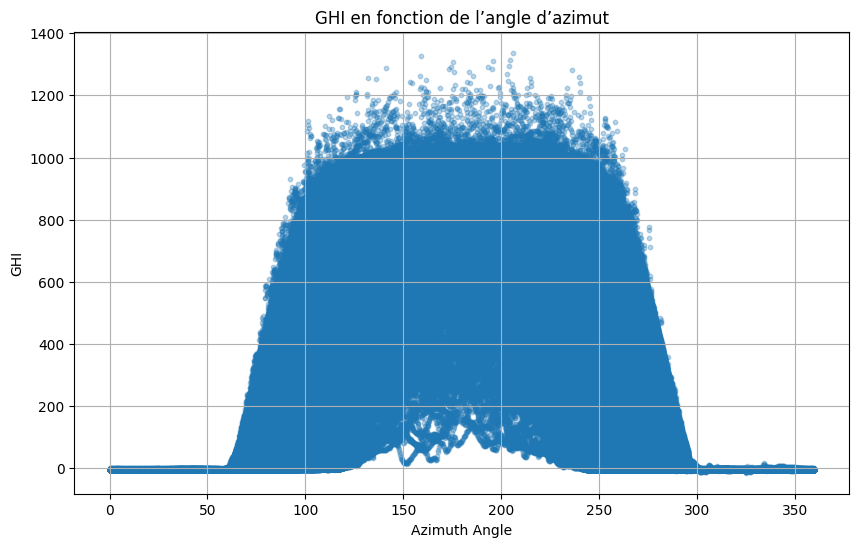

In [27]:
azimuth_col = (
    'Azimuth Angle [degrees]'
    if 'Azimuth Angle [degrees]' in df_solar.columns else
    'azimuth angle'
    if 'azimuth angle' in df_solar.columns else
    'azimuth'
    if 'azimuth' in df_solar.columns else
    None
)

if azimuth_col is None:
    raise KeyError('Aucune colonne azimuth identifiable.: ', df_solar.columns)

plt.figure(figsize=(10, 6))
plt.scatter(df_solar[azimuth_col], df_solar['ghi'], alpha=0.3, s=10)
plt.title('GHI en fonction de l’angle d’azimut')
plt.xlabel('Azimuth Angle')
plt.ylabel('GHI')
plt.grid(True)
plt.show()

17. Créez un nuage de points pour analyser la relation entre :

● l’angle zénithal (Zenith Angle [degrees]) en abscisse,

● le rayonnement GHI en ordonnée.

Existe-t-il une tendance ou un comportement remarquable dans ce graphique ? Expliquez.

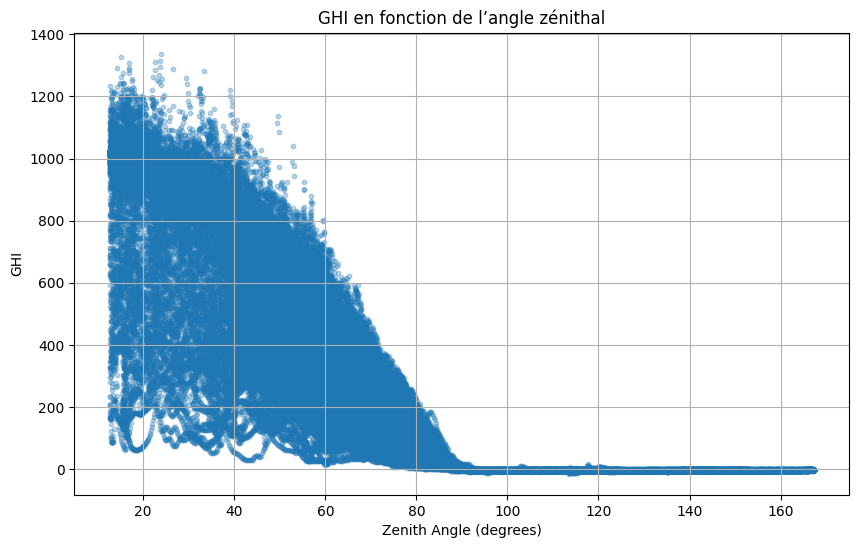

In [28]:
zenith_col = (
    'Zenith Angle [degrees]'
    if 'Zenith Angle [degrees]' in df_solar.columns else
    'zenith angle'
    if 'zenith angle' in df_solar.columns else
    'zenith'
    if 'zenith' in df_solar.columns else
    None
)

if zenith_col is None:
    raise KeyError('Aucune colonne zenith identifiable.')

plt.figure(figsize=(10, 6))
plt.scatter(df_solar[zenith_col], df_solar['ghi'], alpha=0.3, s=10)
plt.title('GHI en fonction de l’angle zénithal')
plt.xlabel('Zenith Angle (degrees)')
plt.ylabel('GHI')
plt.grid(True)
plt.show()

18. Créez un nuage de points représentant :

● l’angle d’azimut en abscisse,

● l’angle zénithal en ordonnée,

et utilisez la variable “GHI” comme code couleur pour les points.

● Le résultat obtenu confirme-t-il les conclusions précédentes concernant la relation
entre GHI, azimut et zénith ?

● Justifiez votre réponse à l’aide du graphique.

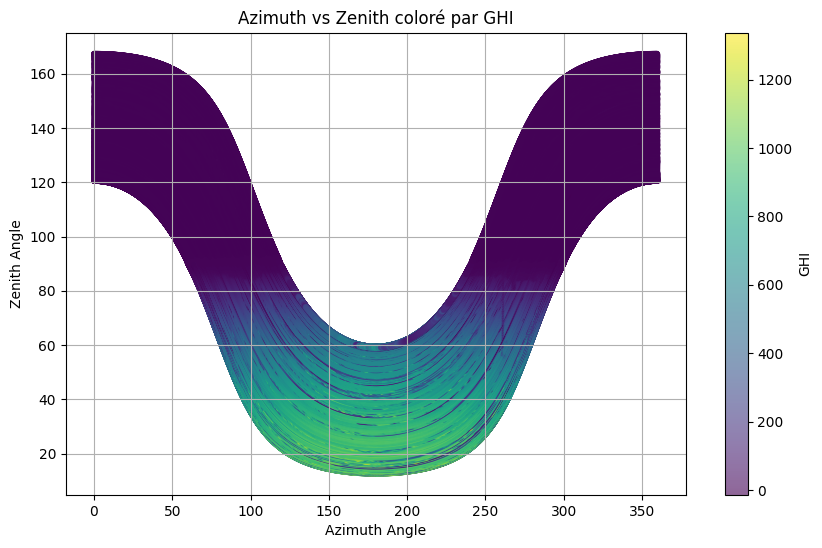

In [29]:
azimuth_col = (
    'Azimuth Angle [degrees]'
    if 'Azimuth Angle [degrees]' in df_solar.columns else
    'azimuth angle'
    if 'azimuth angle' in df_solar.columns else
    'azimuth'
    if 'azimuth' in df_solar.columns else
    None
)
zenith_col = (
    'Zenith Angle [degrees]'
    if 'Zenith Angle [degrees]' in df_solar.columns else
    'zenith angle'
    if 'zenith angle' in df_solar.columns else
    'zenith'
    if 'zenith' in df_solar.columns else
    None
)

if azimuth_col is None or zenith_col is None:
    raise KeyError('Colonne azimuth ou zenith introuvable')

plt.figure(figsize=(10, 6))
plt.scatter(df_solar[azimuth_col], df_solar[zenith_col], c=df_solar['ghi'], cmap='viridis', s=10, alpha=0.6)
plt.colorbar(label='GHI')
plt.title('Azimuth vs Zenith coloré par GHI')
plt.xlabel('Azimuth Angle')
plt.ylabel('Zenith Angle')
plt.grid(True)
plt.show()

19. Affichez un graphique de densité de probabilité bidimensionnelle (KDE 2D) pour
analyser :

● la relation entre le rayonnement GHI et la température.

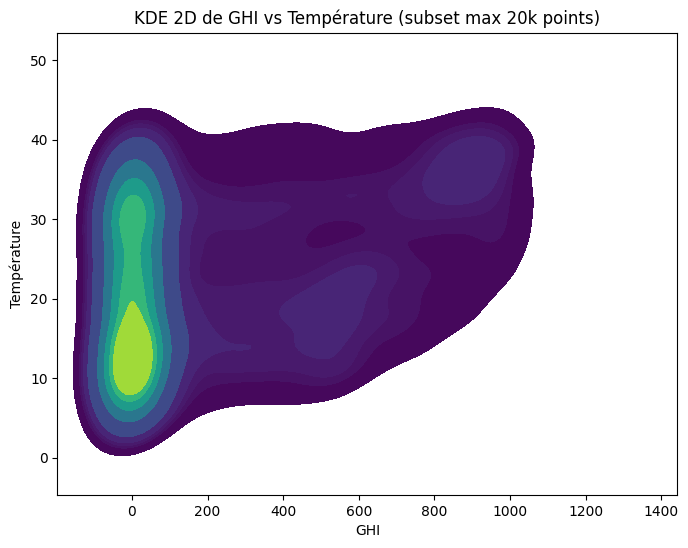

In [30]:
plt.figure(figsize=(8, 6))
# Réduire le nombre de points pour éviter que KDE ne soit trop lent sur très grand dataset
kde_sample = df_solar[['ghi', 'temp']].dropna()
if len(kde_sample) > 20000:
    kde_sample = kde_sample.sample(n=20000, random_state=42)

sns.kdeplot(x=kde_sample['ghi'], y=kde_sample['temp'], cmap='viridis', fill=True, thresh=0.05)
plt.title('KDE 2D de GHI vs Température (subset max 20k points)')
plt.xlabel('GHI')
plt.ylabel('Température')
plt.show()

Ensuite, réalisez un autre KDE 2D pour étudier la relation entre :

● la vitesse du vent (wind speed),

● la direction du vent (wind direction).


In [31]:
wind_speed_col = 'wind speed' if 'wind speed' in df_solar.columns else 'wind_speed' if 'wind_speed' in df_solar.columns else 'wind speed (mph)' if 'wind speed (mph)' in df_solar.columns else None
wind_dir_col = 'wind direction' if 'wind direction' in df_solar.columns else 'wind_direction' if 'wind_direction' in df_solar.columns else None

if wind_speed_col is None or wind_dir_col is None:
    print('Attention : colonnes vent non trouvées, passez à la question 20.')
else:
    plt.figure(figsize=(8, 6))
    sns.kdeplot(x=df_solar[wind_speed_col], y=df_solar[wind_dir_col], cmap='magma', fill=True, thresh=0.05)
    plt.title('KDE 2D de la vitesse et la direction du vent')
    plt.xlabel('Wind Speed')
    plt.ylabel('Wind Direction')
    plt.show()

Attention : colonnes vent non trouvées, passez à la question 20.


20. Tracez la distribution des variables suivantes sous forme de sous-graphiques
(subplots) :

● la vitesse du vent

● la direction du vent,

● la température

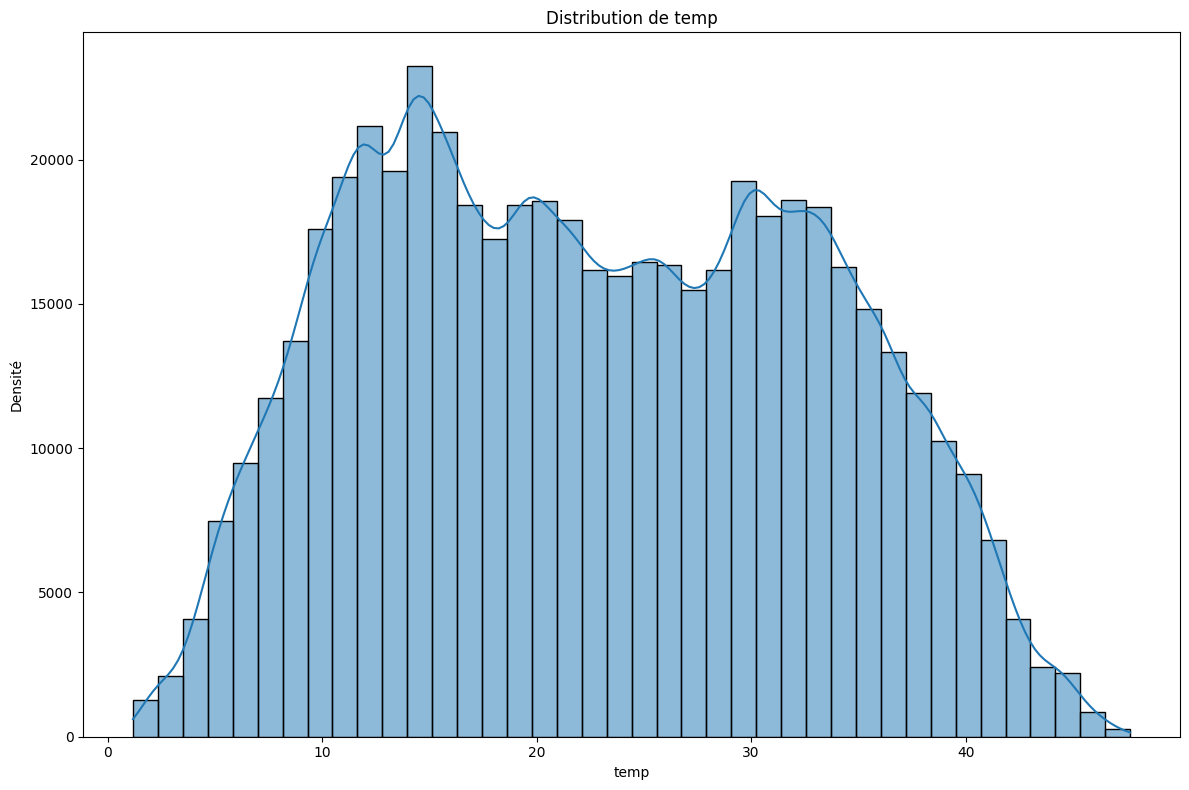

In [32]:
cols_20 = []
if wind_speed_col is not None:
    cols_20.append(wind_speed_col)
if wind_dir_col is not None:
    cols_20.append(wind_dir_col)
if 'temp' in df_solar.columns:
    cols_20.append('temp')

if len(cols_20) == 0:
    raise KeyError('Aucune des colonnes pour Q20 trouvées.')

plt.figure(figsize=(12, 8))
for i, col in enumerate(cols_20, start=1):
    plt.subplot(len(cols_20), 1, i)
    sns.histplot(df_solar[col], kde=True, bins=40)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Densité')

plt.tight_layout()
plt.show()

21. Tracez un graphique KDE bidimensionnel (2D) illustrant la distribution conjointe
des variables :

● DHI (Diffuse Horizontal Irradiance),

● DNI (Direct Normal Irradiance)

1.5 Investigation des différences

22. Créez une figure unique contenant les courbes KDE (qui montrent la densité)
de ‘DHI’ et ‘DNI’

23. Fournissez un pair plot qui représente toutes les relations par paires dans le
dataset en utilisant la méthode correspondante de la bibliothèque Seaborn.
Que pouvez-vous en conclure ?

1.6 Investigation supplémentaire
Créez un nuage de points 3D avec les variables (x, y, z) : où ‘DNI’, ‘DHI’ et ‘GHI’
représentent respectivement les axes x, y et z.
Vous pouvez utiliser le code suivant :

ax = plt.axes(projection='3d')

ax.scatter3D(x, y, z)

● Que pouvez-vous conclure à partir de ce graphique ?

1.7 Échantillonnage descendant et ascendant des séries temporelles
Lors de l’évaluation des ressources solaires, il se peut que vous ayez besoin d’une
résolution temporelle différente de celle de vos données pour une partie particulière de
l’analyse. Dans ces cas, il est possible de rééchantillonner à la baisse (down-sampling) ou à
la hausse (up-sampling) les données à différentes résolutions temporelles en utilisant deux
méthodes de la bibliothèque Pandas appelées resample et asfreq.
Selon vos besoins, vous choisirez l’une ou l’autre méthode.

Quelle que soit la méthode utilisée, les deux nécessitent un DataFrame avec un
DatetimeIndex, soit conscient du temps (time-aware / localisé), soit non conscient du temps
(time-naive / non localisé).

Quelle est la différence entre ces deux types ? Essayez d’expliquer la différence en détail

● Tracez la variation de ‘GHI’ pour des intervalles de 30 minutes, 1 heure et 1 semaine.
Que pouvez-vous en conclure ?

● Tracez la variation de ‘GHI’, ‘DHI’, ‘DNI’ et de la température pour des intervalles de
deux semaines sous forme de subplots.